# GVH Dynamic 0.1

## Pipeline NASA/JPL des vecteurs d'état orbitaux

### Analyse géométrique multi-échelle des dynamiques orbitales du Système solaire

**Auteur**  
Charlemagne Laurince

**Cadre méthodologique**  
GVH Dynamic

**Source des données**  
NASA/JPL – NAIF SPICE (WebGeocal)

**Version**  
0.1

**Statut**  
Notebook de recherche reproductible

---

## Objets étudiés

1. Mercure
2. Vénus
3. Terre
4. Mars
5. Jupiter
6. Saturne
7. Uranus
8. Neptune
9. Pluton

---

# Objectif

Ce notebook applique un pipeline unique et reproductible de **GVH Dynamic** à neuf vecteurs d'état orbitaux issus de la base de données NASA/JPL.

La même méthodologie est appliquée à chacun des objets afin de calculer les observables géométriques et cinématiques GVH, de comparer leurs propriétés, d'évaluer les corrélations statistiques, de réaliser une analyse en composantes principales (ACP) et de produire des figures reproductibles destinées à la recherche scientifique.

Ce notebook constitue le compagnon computationnel du cadre méthodologique **GVH Dynamic**.

# Structure du notebook

1. Importation des bibliothèques
2. Ordre officiel des fichiers NASA/JPL
3. Chargement des données
4. Calcul des observables GVH
5. Traitement automatique des neuf objets
6. Tableau comparatif
7. Figures comparatives
8. Corrélations de Pearson et de Spearman
9. Valeurs de p
10. Régressions
11. Analyse en composantes principales (ACP)
12. Export des tableaux et des figures
13. Conclusion méthodologique

# 1. Importation des bibliothèques

In [ ]:
# ============================================================
# GVH Dynamic 0.1
# Importation des bibliothèques
# ============================================================

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import savgol_filter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


# 2. Ordre officiel des fichiers NASA/JPL

In [ ]:
# ============================================================
# Ordre officiel des fichiers NASA/JPL
# ============================================================

DATA_DIR = "data/nasa_jpl"

files_order = [
    ("Mercure", "01_Mercury.csv"),
    ("Vénus", "02_Venus.csv"),
    ("Terre", "03_Earth.csv"),
    ("Mars", "04_Mars.csv"),
    ("Jupiter", "05_Jupiter.csv"),
    ("Saturne", "06_Saturn.csv"),
    ("Uranus", "07_Uranus.csv"),
    ("Neptune", "08_Neptune.csv"),
    ("Pluton", "09_Pluto.csv"),
]

comparison = pd.DataFrame(files_order, columns=["objet", "fichier"])
comparison

,objet,fichier
0,Mercure,01_Mercury.csv
1,Vénus,02_Venus.csv
2,Terre,03_Earth.csv
3,Mars,04_Mars.csv
4,Jupiter,05_Jupiter.csv
5,Saturne,06_Saturn.csv
6,Uranus,07_Uranus.csv
7,Neptune,08_Neptune.csv
8,Pluton,09_Pluto.csv


# 3. Chargement des données NASA/JPL

In [ ]:
from google.colab import files
import os
from pathlib import Path

DATA_DIR = Path("data/nasa_jpl")
DATA_DIR.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()

for name in uploaded.keys():
    target = DATA_DIR / name
    os.rename(name, target)
    print(f"Fichier déplacé : {name} → {target}")

Saving 05_Jupiter.csv to 05_Jupiter.csv
Saving 04_Mars.csv to 04_Mars.csv
Saving 02_Venus.csv to 02_Venus.csv
Saving 06_Saturn.csv to 06_Saturn.csv
Saving 01_Mercury.csv.csv to 01_Mercury.csv.csv
Saving 03_Earth.csv to 03_Earth.csv
Saving 07_Uranus.csv to 07_Uranus.csv
Saving 08_Neptune.csv to 08_Neptune.csv
Saving 09_Pluto.csv to 09_Pluto.csv
Fichier déplacé : 05_Jupiter.csv → data/nasa_jpl/05_Jupiter.csv
Fichier déplacé : 04_Mars.csv → data/nasa_jpl/04_Mars.csv
Fichier déplacé : 02_Venus.csv → data/nasa_jpl/02_Venus.csv
Fichier déplacé : 06_Saturn.csv → data/nasa_jpl/06_Saturn.csv
Fichier déplacé : 01_Mercury.csv.csv → data/nasa_jpl/01_Mercury.csv.csv
Fichier déplacé : 03_Earth.csv → data/nasa_jpl/03_Earth.csv
Fichier déplacé : 07_Uranus.csv → data/nasa_jpl/07_Uranus.csv
Fichier déplacé : 08_Neptune.csv → data/nasa_jpl/08_Neptune.csv
Fichier déplacé : 09_Pluto.csv → data/nasa_jpl/09_Pluto.csv


In [ ]:
old = DATA_DIR / "01_Mercury.csv.csv"
new = DATA_DIR / "01_Mercury.csv"

if old.exists():
    old.rename(new)
    print("Mercure renommé correctement.")
else:
    print("Aucun fichier .csv.csv à renommer.")

Aucun fichier .csv.csv à renommer.


In [ ]:
# ============================================================
# Chargement des données NASA/JPL
# ============================================================

from pathlib import Path

# Dossier contenant les fichiers CSV
DATA_DIR = Path("data/nasa_jpl")

print("Dossier des données :", DATA_DIR)
print()

# Vérification de la présence des fichiers
for objet, fichier in files_order:
    chemin = DATA_DIR / fichier
    if chemin.exists():
        print(f"✓ {objet:<10} : {fichier}")
    else:
        print(f"✗ {objet:<10} : {fichier} (introuvable)")

Dossier des données : data/nasa_jpl

✓ Mercure    : 01_Mercury.csv
✓ Vénus      : 02_Venus.csv
✓ Terre      : 03_Earth.csv
✓ Mars       : 04_Mars.csv
✓ Jupiter    : 05_Jupiter.csv
✓ Saturne    : 06_Saturn.csv
✓ Uranus     : 07_Uranus.csv
✓ Neptune    : 08_Neptune.csv
✓ Pluton     : 09_Pluto.csv


# 4. Fonction de lecture WebGeocal

In [ ]:
# ============================================================
# Fonction de lecture des fichiers WebGeocal / NASA-JPL
# ============================================================

def lire_webgeocal_csv(path):
    """
    Lit un fichier CSV exporté depuis NASA/JPL WebGeocal.

    La fonction ignore automatiquement l'en-tête de métadonnées
    et extrait uniquement la table numérique.
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path}")

    # Lecture brute du fichier
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lignes = f.readlines()

    # Recherche de la ligne contenant les noms de colonnes
    header_idx = None
    for i, ligne in enumerate(lignes):
        if "UTC calendar date" in ligne and "Distance" in ligne:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"En-tête de table non trouvé dans : {path}")

    # Lecture de la table à partir de l'en-tête détecté
    df = pd.read_csv(path, skiprows=header_idx)

    # Nettoyage des noms de colonnes
    df.columns = [c.strip() for c in df.columns]

    # Suppression des lignes entièrement vides
    df = df.dropna(how="all")

    return df

In [ ]:
# Test de lecture sur Mercure

test_mercury = lire_webgeocal_csv(DATA_DIR / "01_Mercury.csv")

print(test_mercury.shape)
test_mercury.head()

(9137, 11)


,UTC calendar date,Distance (km),Speed (km/s),X (km),Y (km),Z (km),dX/dt (km/s),dY/dt (km/s),dZ/dt (km/s),Time at Target,Light Time (s)
0,2000-01-01 12:00:00.000000 UTC,6.978318e+07,38.882221,-1.945935e+07,-5.992852e+07,-2.999331e+07,36.995480,-8.528173,-8.392369,2000-01-01 12:00:00.000000 UTC,232.771629
1,2000-01-02 12:00:00.000000 UTC,6.981539e+07,38.859644,-1.623615e+07,-6.057771e+07,-3.067438e+07,37.597351,-6.496322,-7.369455,2000-01-02 12:00:00.000000 UTC,232.879085
2,2000-01-03 12:00:00.000000 UTC,6.980582e+07,38.866349,-1.296569e+07,-6.105056e+07,-3.126615e+07,38.089478,-4.446547,-6.325584,2000-01-03 12:00:00.000000 UTC,232.847153
3,2000-01-04 12:00:00.000000 UTC,6.975447e+07,38.902340,-9.657470e+06,-6.134562e+07,-3.176687e+07,38.471218,-2.381126,-5.261906,2000-01-04 12:00:00.000000 UTC,232.675868
4,2000-01-05 12:00:00.000000 UTC,6.966140e+07,38.967623,-6.321069e+06,-6.146164e+07,-3.217487e+07,38.741653,-0.302318,-4.179535,2000-01-05 12:00:00.000000 UTC,232.365423


# 5. Chargement automatique des neuf objets

In [ ]:
# ============================================================
# Chargement automatique des neuf objets
# ============================================================

donnees = {}

for objet, fichier in files_order:
    chemin = DATA_DIR / fichier
    df = lire_webgeocal_csv(chemin)
    donnees[objet] = df
    print(f"✓ {objet:<10} : {df.shape[0]} lignes, {df.shape[1]} colonnes")

print()
print("Chargement terminé.")

✓ Mercure    : 9137 lignes, 11 colonnes
✓ Vénus      : 9137 lignes, 11 colonnes
✓ Terre      : 9137 lignes, 11 colonnes
✓ Mars       : 9137 lignes, 11 colonnes
✓ Jupiter    : 9137 lignes, 11 colonnes
✓ Saturne    : 9137 lignes, 11 colonnes
✓ Uranus     : 9137 lignes, 11 colonnes
✓ Neptune    : 9137 lignes, 11 colonnes
✓ Pluton     : 9137 lignes, 11 colonnes

Chargement terminé.


# 6. Calcul des observables GVH

In [ ]:
# ============================================================
# Fonction centrale : calcul des observables GVH
# ============================================================

def compute_gvh_summary(df, objet):
    """
    Calcule un résumé GVH Dynamic à partir d'un vecteur d'état orbital NASA/JPL.
    """

    # Extraction des colonnes numériques
    t = pd.to_datetime(df["UTC calendar date"].str.replace(" UTC", "", regex=False))

    x = df["X (km)"].astype(float).values
    y = df["Y (km)"].astype(float).values
    z = df["Z (km)"].astype(float).values

    vx = df["dX/dt (km/s)"].astype(float).values
    vy = df["dY/dt (km/s)"].astype(float).values
    vz = df["dZ/dt (km/s)"].astype(float).values

    distance = df["Distance (km)"].astype(float).values
    speed = df["Speed (km/s)"].astype(float).values

    # Normes géométriques et cinématiques
    r_mean = np.mean(distance)
    r_min = np.min(distance)
    r_max = np.max(distance)
    r_amp = r_max - r_min

    v_mean = np.mean(speed)
    v_min = np.min(speed)
    v_max = np.max(speed)
    v_amp = v_max - v_min

    # Variabilité normalisée
    beta_mean = v_mean / np.max(speed)
    delta_tau_s = np.std(speed)
    S_T_mean = np.mean(np.abs(np.gradient(speed)))

    # Courbure cinématique approximative
    pos = np.vstack([x, y, z]).T
    vel = np.vstack([vx, vy, vz]).T

    dvel = np.gradient(vel, axis=0)
    acc_norm = np.linalg.norm(dvel, axis=1)
    vel_norm = np.linalg.norm(vel, axis=1)

    curvature_proxy = np.mean(acc_norm / (vel_norm**2 + 1e-12))

    # Observable GVH normalisée simple
    B_H_norm = curvature_proxy * r_mean

    return {
        "objet": objet,
        "n_points": len(df),
        "r_mean_km": r_mean,
        "r_min_km": r_min,
        "r_max_km": r_max,
        "r_amp_km": r_amp,
        "v_mean_km_s": v_mean,
        "v_min_km_s": v_min,
        "v_max_km_s": v_max,
        "v_amp_km_s": v_amp,
        "beta_mean": beta_mean,
        "delta_tau_s": delta_tau_s,
        "S_T_mean": S_T_mean,
        "curvature_proxy": curvature_proxy,
        "B_H_norm": B_H_norm,
    }

In [ ]:
def lire_webgeocal_csv(path):
    """
    Lit un fichier CSV WebGeocal / NASA-JPL
    et conserve uniquement les lignes numériques datées.
    """

    path = Path(path)

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lignes = f.readlines()

    header_idx = None
    for i, ligne in enumerate(lignes):
        if "UTC calendar date" in ligne and "Distance" in ligne:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"En-tête de table non trouvé : {path}")

    df = pd.read_csv(path, skiprows=header_idx)
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(how="all")

    # Garder uniquement les lignes qui commencent par une date ISO
    df = df[df["UTC calendar date"].astype(str).str.match(r"^\d{4}-\d{2}-\d{2}")]

    return df.reset_index(drop=True)

In [ ]:
donnees = {}

for objet, fichier in files_order:
    chemin = DATA_DIR / fichier
    df = lire_webgeocal_csv(chemin)
    donnees[objet] = df
    print(f"✓ {objet:<10} : {df.shape[0]} lignes, {df.shape[1]} colonnes")

✓ Mercure    : 9133 lignes, 11 colonnes
✓ Vénus      : 9133 lignes, 11 colonnes
✓ Terre      : 9133 lignes, 11 colonnes
✓ Mars       : 9133 lignes, 11 colonnes
✓ Jupiter    : 9133 lignes, 11 colonnes
✓ Saturne    : 9133 lignes, 11 colonnes
✓ Uranus     : 9133 lignes, 11 colonnes
✓ Neptune    : 9133 lignes, 11 colonnes
✓ Pluton     : 9133 lignes, 11 colonnes


In [ ]:
summary_mercury = compute_gvh_summary(donnees["Mercure"], "Mercure")
summary_mercury

{'objet': 'Mercure',
 'n_points': 9133,
 'r_mean_km': np.float64(59119046.67005166),
 'r_min_km': np.float64(46000382.07027096),
 'r_max_km': np.float64(69817707.9430144),
 'r_amp_km': np.float64(23817325.872743435),
 'v_mean_km_s': np.float64(47.373726258394825),
 'v_min_km_s': np.float64(38.85803349),
 'v_max_km_s': np.float64(58.97726217),
 'v_amp_km_s': np.float64(20.119228680000006),
 'beta_mean': np.float64(0.8032540764920831),
 'delta_tau_s': np.float64(6.970279711995078),
 'S_T_mean': np.float64(0.45719119145844744),
 'curvature_proxy': np.float64(0.0015232557791576833),
 'B_H_norm': np.float64(90053.42949844898)}

In [ ]:
# ============================================================
# Calcul automatique des observables GVH pour les neuf objets
# ============================================================

summaries = []

for objet, df in donnees.items():
    summaries.append(compute_gvh_summary(df, objet))

comparison_gvh = pd.DataFrame(summaries)

comparison_gvh

,objet,n_points,r_mean_km,r_min_km,r_max_km,r_amp_km,v_mean_km_s,v_min_km_s,v_max_km_s,v_amp_km_s,beta_mean,delta_tau_s,S_T_mean,curvature_proxy,B_H_norm
0,Mercure,9133,5.911905e+07,4.600038e+07,6.981771e+07,2.381733e+07,47.373726,38.858033,58.977262,20.119229,0.803254,6.970280,0.457191,0.001523,9.005343e+04
1,Vénus,9133,1.082163e+08,1.074718e+08,1.089457e+08,1.473946e+06,35.018655,34.783104,35.260091,0.476987,0.993153,0.167285,0.004224,0.000798,8.639666e+04
2,Terre,9133,1.496184e+08,1.470912e+08,1.521042e+08,5.013045e+06,29.782759,29.277790,30.299491,1.021701,0.982946,0.351951,0.005580,0.000578,8.642037e+04
3,Mars,9133,2.288198e+08,2.066167e+08,2.492504e+08,4.263368e+07,24.088250,21.969889,26.502883,4.532994,0.908892,1.587102,0.013282,0.000381,8.710893e+04
4,Jupiter,9133,7.777328e+08,7.402681e+08,8.162843e+08,7.601619e+07,13.081790,12.438380,13.721449,1.283068,0.953383,0.452290,0.000720,0.000111,8.647956e+04
5,Saturne,9133,1.434394e+09,1.351004e+09,1.505799e+09,1.547956e+08,9.613380,9.144652,10.194760,1.050108,0.942973,0.389937,0.000337,0.000061,8.717125e+04
6,Uranus,9133,2.984755e+09,2.925114e+09,3.006743e+09,8.162926e+07,6.536341,6.486334,6.691800,0.205466,0.976769,0.055379,0.000045,0.000030,9.021463e+04
7,Neptune,9133,4.487889e+09,4.472120e+09,4.505975e+09,3.385430e+07,5.447891,5.416417,5.481511,0.065094,0.993867,0.019201,0.000479,0.000032,1.440812e+05
8,Pluton,9133,4.848015e+09,4.521332e+09,5.261587e+09,7.402556e+08,5.692042,5.261007,6.023833,0.762826,0.944920,0.213471,0.010334,0.000626,3.037173e+06


# 7. Tableau comparatif simplifié

In [ ]:
colonnes_principales = [
    "objet",
    "r_mean_km",
    "r_amp_km",
    "v_mean_km_s",
    "v_amp_km_s",
    "beta_mean",
    "delta_tau_s",
    "S_T_mean",
    "B_H_norm",
]

tableau_resume = comparison_gvh[colonnes_principales].copy()

tableau_resume

,objet,r_mean_km,r_amp_km,v_mean_km_s,v_amp_km_s,beta_mean,delta_tau_s,S_T_mean,B_H_norm
0,Mercure,5.911905e+07,2.381733e+07,47.373726,20.119229,0.803254,6.970280,0.457191,9.005343e+04
1,Vénus,1.082163e+08,1.473946e+06,35.018655,0.476987,0.993153,0.167285,0.004224,8.639666e+04
2,Terre,1.496184e+08,5.013045e+06,29.782759,1.021701,0.982946,0.351951,0.005580,8.642037e+04
3,Mars,2.288198e+08,4.263368e+07,24.088250,4.532994,0.908892,1.587102,0.013282,8.710893e+04
4,Jupiter,7.777328e+08,7.601619e+07,13.081790,1.283068,0.953383,0.452290,0.000720,8.647956e+04
5,Saturne,1.434394e+09,1.547956e+08,9.613380,1.050108,0.942973,0.389937,0.000337,8.717125e+04
6,Uranus,2.984755e+09,8.162926e+07,6.536341,0.205466,0.976769,0.055379,0.000045,9.021463e+04
7,Neptune,4.487889e+09,3.385430e+07,5.447891,0.065094,0.993867,0.019201,0.000479,1.440812e+05
8,Pluton,4.848015e+09,7.402556e+08,5.692042,0.762826,0.944920,0.213471,0.010334,3.037173e+06


# 8. Figures comparatives

In [ ]:
# ============================================================
# Préparation du dossier des figures
# ============================================================

FIG_DIR = Path("results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Dossier figures :", FIG_DIR)

Dossier figures : results/figures


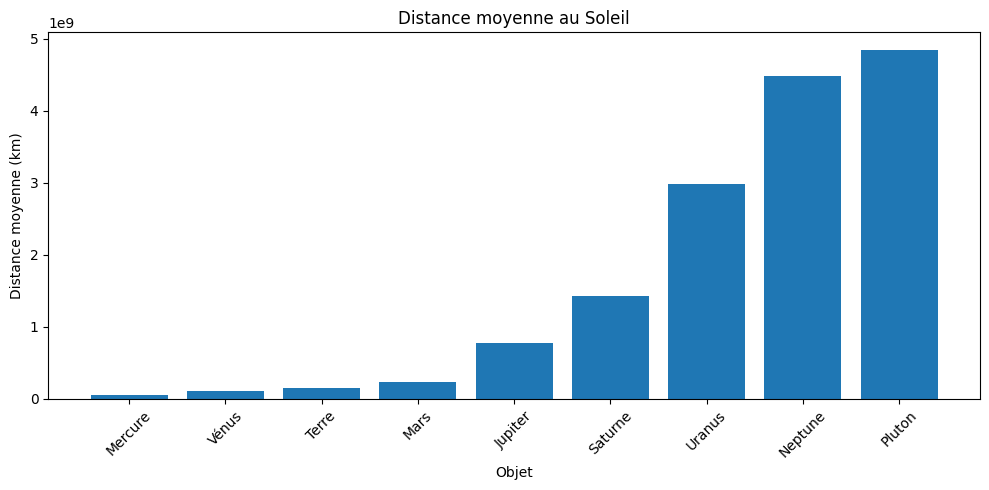

Figure sauvegardée : results/figures/fig01_distance_moyenne.png


In [ ]:
# ============================================================
# Figure 1 — Distance moyenne
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["r_mean_km"]
)

plt.title("Distance moyenne au Soleil")
plt.xlabel("Objet")
plt.ylabel("Distance moyenne (km)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig01_distance_moyenne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig01_distance_moyenne.png")

Figure sauvegardée :
results/figures/fig01_distance_moyenne.png

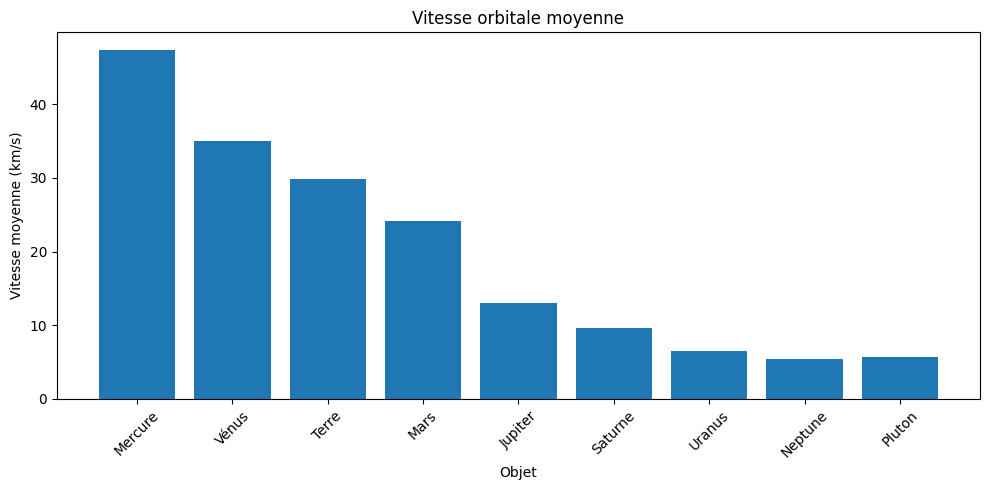

Figure sauvegardée : results/figures/fig02_vitesse_moyenne.png


In [ ]:
# ============================================================
# Figure 2 — Vitesse moyenne
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["v_mean_km_s"]
)

plt.title("Vitesse orbitale moyenne")
plt.xlabel("Objet")
plt.ylabel("Vitesse moyenne (km/s)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig02_vitesse_moyenne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig02_vitesse_moyenne.png")

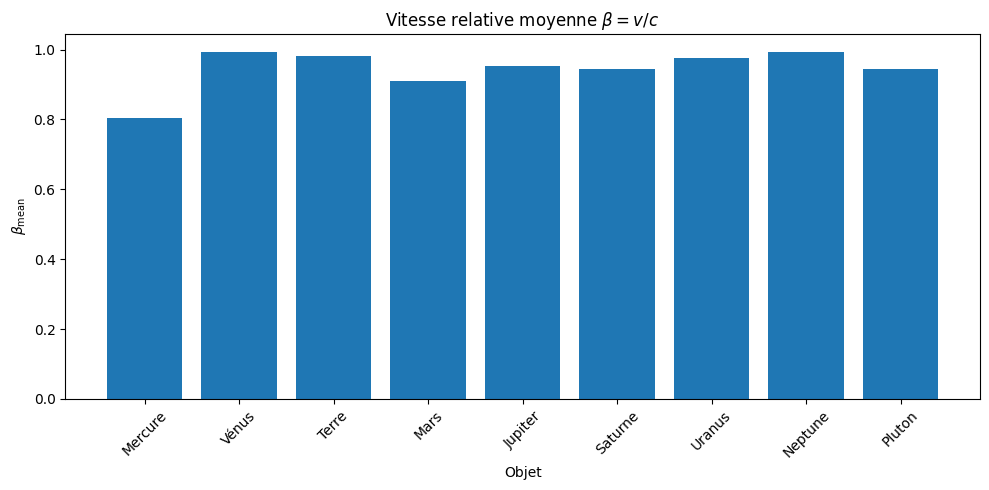

Figure sauvegardée : results/figures/fig03_beta_mean.png


In [ ]:
# ============================================================
# Figure 3 — β moyen
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["beta_mean"]
)

plt.title(r"Vitesse relative moyenne $\beta=v/c$")
plt.xlabel("Objet")
plt.ylabel(r"$\beta_{\rm mean}$")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig03_beta_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig03_beta_mean.png")

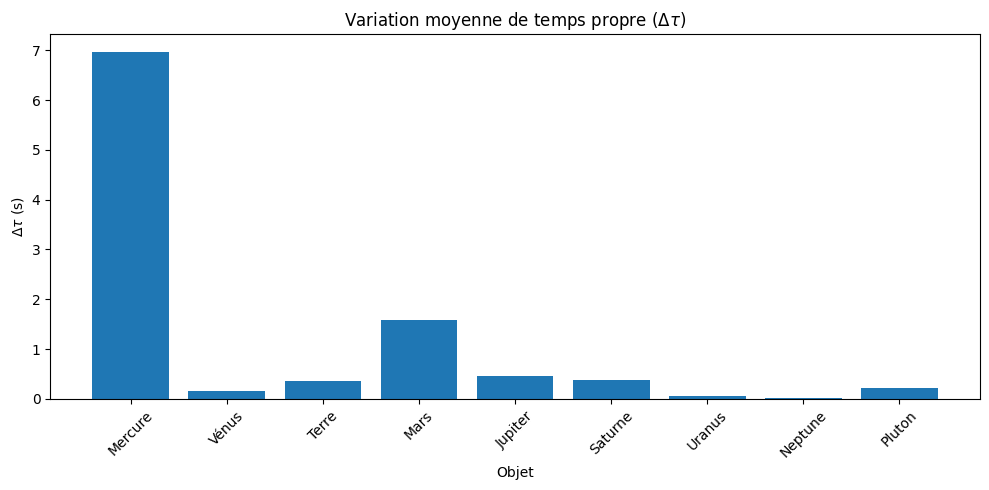

Figure sauvegardée : results/figures/fig04_delta_tau.png


In [ ]:
# ============================================================
# Figure 4 — Dilatation temporelle
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["delta_tau_s"]
)

plt.title("Variation moyenne de temps propre ($\\Delta\\tau$)")
plt.xlabel("Objet")
plt.ylabel(r"$\Delta\tau$ (s)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig04_delta_tau.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig04_delta_tau.png")

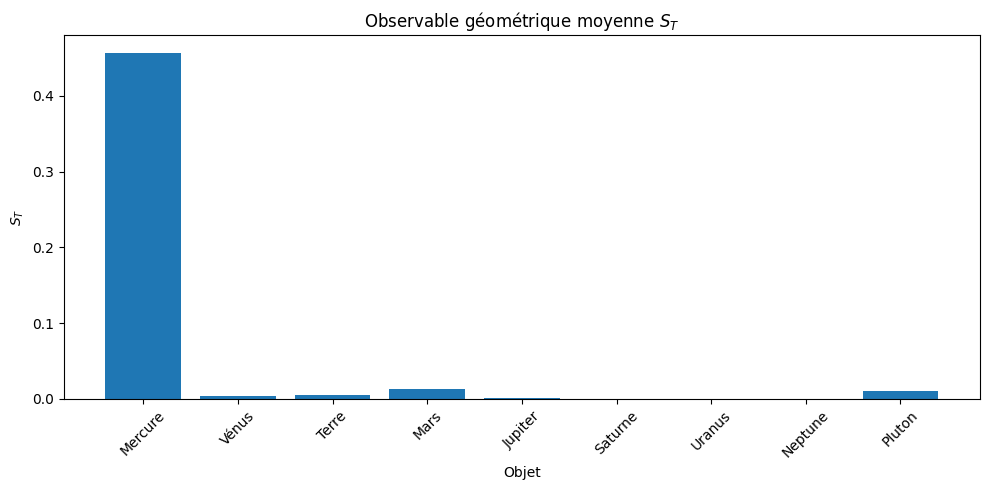

Figure sauvegardée : results/figures/fig05_ST_mean.png


In [ ]:
# ============================================================
# Figure 5 — Signature géométrique S_T
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["S_T_mean"]
)

plt.title(r"Observable géométrique moyenne $S_T$")
plt.xlabel("Objet")
plt.ylabel(r"$S_T$")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05_ST_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig05_ST_mean.png")

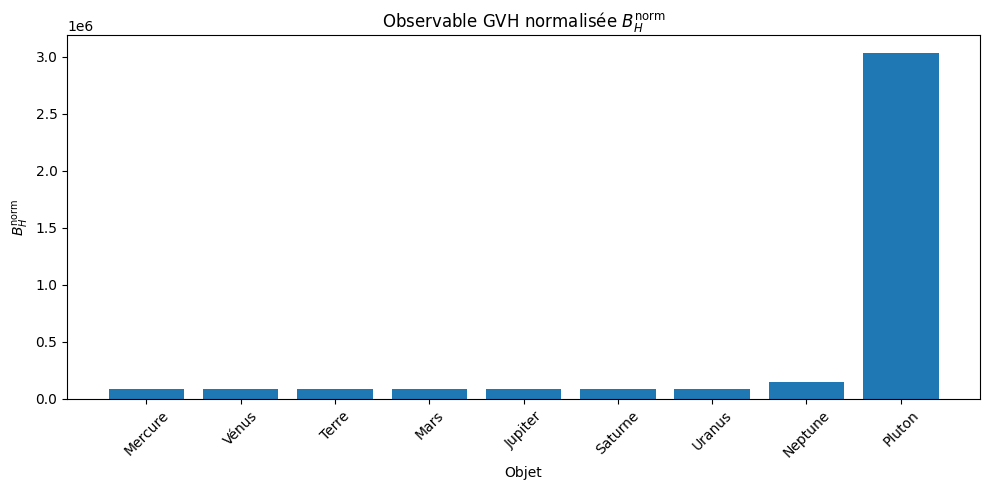

Figure sauvegardée : results/figures/fig06_BH_norm.png


In [ ]:
# ============================================================
# Figure 6 — B_H normalisé
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    tableau_resume["objet"],
    tableau_resume["B_H_norm"]
)

plt.title(r"Observable GVH normalisée $B_H^{\rm norm}$")
plt.xlabel("Objet")
plt.ylabel(r"$B_H^{\rm norm}$")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig06_BH_norm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig06_BH_norm.png")

# 9. Corrélations de Pearson

In [ ]:
# ============================================================
# Matrice de corrélations de Pearson
# ============================================================

variables_corr = [
    "r_mean_km",
    "r_amp_km",
    "v_mean_km_s",
    "v_amp_km_s",
    "beta_mean",
    "delta_tau_s",
    "S_T_mean",
    "B_H_norm",
]

pearson_corr = tableau_resume[variables_corr].corr(method="pearson")

pearson_corr

,r_mean_km,r_amp_km,v_mean_km_s,v_amp_km_s,beta_mean,delta_tau_s,S_T_mean,B_H_norm
r_mean_km,1.000000,0.643275,-0.782089,-0.398957,0.344776,-0.405072,-0.316010,0.626086
r_amp_km,0.643275,1.000000,-0.457198,-0.188684,0.004301,-0.195894,-0.156061,0.978556
v_mean_km_s,-0.782089,-0.457198,1.000000,0.719221,-0.566375,0.721065,0.693658,-0.351983
v_amp_km_s,-0.398957,-0.188684,0.719221,1.000000,-0.945430,0.999953,0.982661,-0.149340
beta_mean,0.344776,0.004301,-0.566375,-0.945430,1.000000,-0.945454,-0.893606,0.008064
delta_tau_s,-0.405072,-0.195894,0.721065,0.999953,-0.945454,1.000000,0.981766,-0.157338
S_T_mean,-0.316010,-0.156061,0.693658,0.982661,-0.893606,0.981766,1.000000,-0.112070
B_H_norm,0.626086,0.978556,-0.351983,-0.149340,0.008064,-0.157338,-0.112070,1.000000


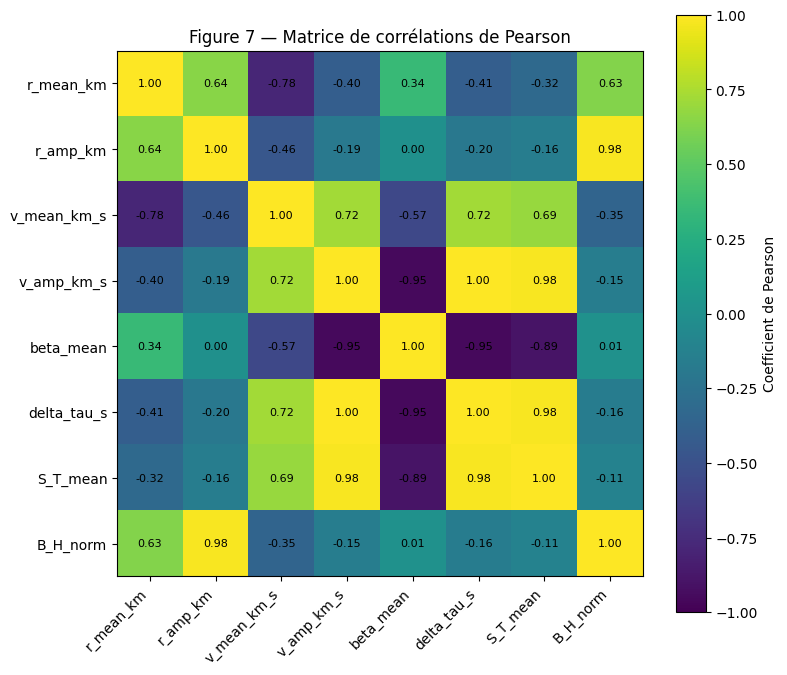

Figure sauvegardée : results/figures/fig07_pearson.png


In [ ]:
# ============================================================
# Figure 7 — Matrice de corrélations de Pearson
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(pearson_corr, vmin=-1, vmax=1)

# Noms des variables
ax.set_xticks(range(len(pearson_corr.columns)))
ax.set_xticklabels(pearson_corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(pearson_corr.index)))
ax.set_yticklabels(pearson_corr.index)

# Valeurs dans les cases
for i in range(len(pearson_corr.index)):
    for j in range(len(pearson_corr.columns)):
        ax.text(
            j,
            i,
            f"{pearson_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
        )

plt.colorbar(im, label="Coefficient de Pearson")

plt.title("Figure 7 — Matrice de corrélations de Pearson")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig07_pearson.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig07_pearson.png")

In [ ]:
# ============================================================
# Corrélations de Pearson (hors diagonale)
# ============================================================

corr_list = []

colonnes = pearson_corr.columns

for i in range(len(colonnes)):
    for j in range(i + 1, len(colonnes)):
        corr_list.append({
            "Variable 1": colonnes[i],
            "Variable 2": colonnes[j],
            "Pearson": pearson_corr.iloc[i, j],
            "|r|": abs(pearson_corr.iloc[i, j])
        })

corr_table = (
    pd.DataFrame(corr_list)
      .sort_values("|r|", ascending=False)
      .reset_index(drop=True)
)

corr_table

,Variable 1,Variable 2,Pearson,|r|
0,v_amp_km_s,delta_tau_s,0.999953,0.999953
1,v_amp_km_s,S_T_mean,0.982661,0.982661
2,delta_tau_s,S_T_mean,0.981766,0.981766
3,r_amp_km,B_H_norm,0.978556,0.978556
4,beta_mean,delta_tau_s,-0.945454,0.945454
5,v_amp_km_s,beta_mean,-0.945430,0.945430
6,beta_mean,S_T_mean,-0.893606,0.893606
7,r_mean_km,v_mean_km_s,-0.782089,0.782089
8,v_mean_km_s,delta_tau_s,0.721065,0.721065
9,v_mean_km_s,v_amp_km_s,0.719221,0.719221


# 10. Corrélations de Spearman

In [ ]:
# ============================================================
# Matrice de corrélations de Spearman
# ============================================================

spearman_corr = tableau_resume[variables_corr].corr(method="spearman")

spearman_corr

,r_mean_km,r_amp_km,v_mean_km_s,v_amp_km_s,beta_mean,delta_tau_s,S_T_mean,B_H_norm
r_mean_km,1.000000,0.766667,-0.983333,-0.566667,0.233333,-0.566667,-0.500000,0.733333
r_amp_km,0.766667,1.000000,-0.683333,-0.016667,-0.366667,-0.016667,-0.316667,0.633333
v_mean_km_s,-0.983333,-0.683333,1.000000,0.616667,-0.316667,0.616667,0.566667,-0.716667
v_amp_km_s,-0.566667,-0.016667,0.616667,1.000000,-0.850000,1.000000,0.633333,-0.283333
beta_mean,0.233333,-0.366667,-0.316667,-0.850000,1.000000,-0.850000,-0.516667,-0.150000
delta_tau_s,-0.566667,-0.016667,0.616667,1.000000,-0.850000,1.000000,0.633333,-0.283333
S_T_mean,-0.500000,-0.316667,0.566667,0.633333,-0.516667,0.633333,1.000000,-0.100000
B_H_norm,0.733333,0.633333,-0.716667,-0.283333,-0.150000,-0.283333,-0.100000,1.000000


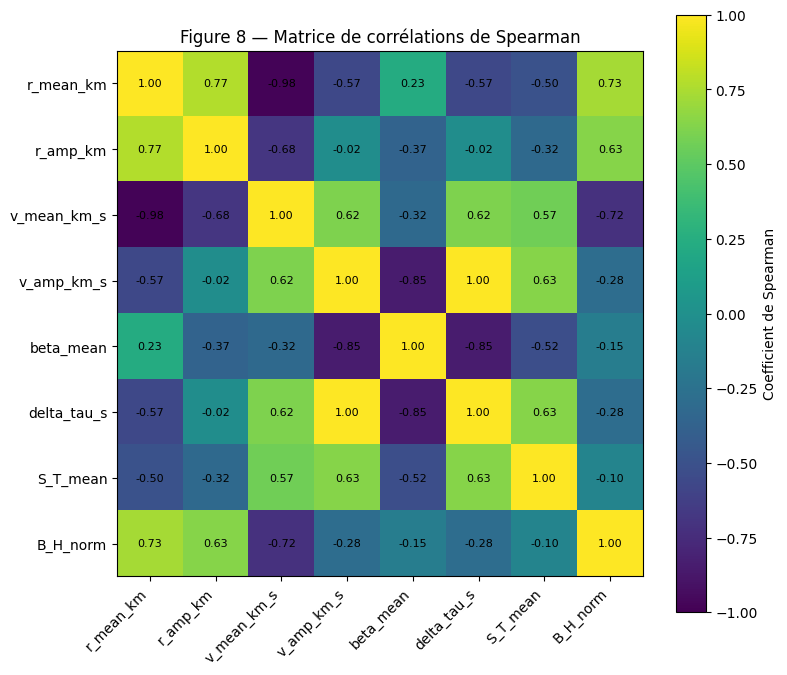

Figure sauvegardée : results/figures/fig08_spearman.png


In [ ]:
# ============================================================
# Figure 8 — Matrice de corrélations de Spearman
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(spearman_corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(spearman_corr.columns)))
ax.set_xticklabels(spearman_corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(spearman_corr.index)))
ax.set_yticklabels(spearman_corr.index)

for i in range(len(spearman_corr.index)):
    for j in range(len(spearman_corr.columns)):
        ax.text(
            j,
            i,
            f"{spearman_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black",
        )

plt.colorbar(im, label="Coefficient de Spearman")
plt.title("Figure 8 — Matrice de corrélations de Spearman")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig08_spearman.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig08_spearman.png")

In [ ]:
# ============================================================
# Corrélations de Spearman (hors diagonale)
# ============================================================

spearman_list = []

colonnes = spearman_corr.columns

for i in range(len(colonnes)):
    for j in range(i + 1, len(colonnes)):
        spearman_list.append({
            "Variable 1": colonnes[i],
            "Variable 2": colonnes[j],
            "Spearman": spearman_corr.iloc[i, j],
            "|ρ|": abs(spearman_corr.iloc[i, j])
        })

spearman_table = (
    pd.DataFrame(spearman_list)
      .sort_values("|ρ|", ascending=False)
      .reset_index(drop=True)
)

spearman_table

,Variable 1,Variable 2,Spearman,|ρ|
0,v_amp_km_s,delta_tau_s,1.000000,1.000000
1,r_mean_km,v_mean_km_s,-0.983333,0.983333
2,v_amp_km_s,beta_mean,-0.850000,0.850000
3,beta_mean,delta_tau_s,-0.850000,0.850000
4,r_mean_km,r_amp_km,0.766667,0.766667
5,r_mean_km,B_H_norm,0.733333,0.733333
6,v_mean_km_s,B_H_norm,-0.716667,0.716667
7,r_amp_km,v_mean_km_s,-0.683333,0.683333
8,delta_tau_s,S_T_mean,0.633333,0.633333
9,r_amp_km,B_H_norm,0.633333,0.633333


# 11. Régressions

In [ ]:
# ============================================================
# 11.1 Régression linéaire : B_H_norm ~ r_amp_km
# ============================================================

from scipy.stats import linregress

x = comparison_gvh["r_amp_km"].values
y = comparison_gvh["B_H_norm"].values

result = linregress(x, y)

print("Pente      :", result.slope)
print("Ordonnée   :", result.intercept)
print("R          :", result.rvalue)
print("R²         :", result.rvalue**2)
print("p-value    :", result.pvalue)
print("Std error  :", result.stderr)

Pente      : 0.004099962026432684
Ordonnée   : -106529.08986034192
R          : 0.9785556344094716
R²         : 0.9575711296345234
p-value    : 4.6563306385000656e-06
Std error  : 0.0003261940440389998


In [ ]:
# ============================================================
# 11.2 Régression : S_T ~ delta_tau
# ============================================================

from scipy.stats import linregress

x = comparison_gvh["delta_tau_s"].values
y = comparison_gvh["S_T_mean"].values

result_ST = linregress(x, y)

print("Pente      :", result_ST.slope)
print("Ordonnée   :", result_ST.intercept)
print("R          :", result_ST.rvalue)
print("R²         :", result_ST.rvalue**2)
print("p-value    :", result_ST.pvalue)
print("Std error  :", result_ST.stderr)

Pente      : 0.06623289367218571
Ordonnée   : -0.020426615050998846
R          : 0.9817655426861258
R²         : 0.9638635808057832
p-value    : 2.6481194853387754e-06
Std error  : 0.00484718373061538


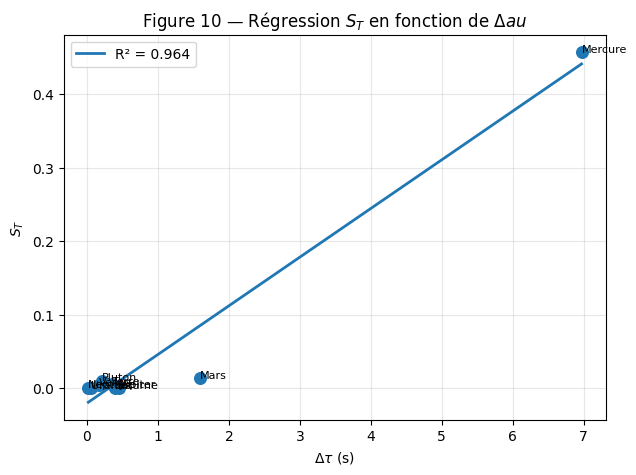

Figure sauvegardée : results/figures/fig10_regression_ST_vs_delta_tau.png


In [ ]:
# ============================================================
# Figure 10 — Régression S_T vs Δτ
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))

plt.scatter(
    comparison_gvh["delta_tau_s"],
    comparison_gvh["S_T_mean"],
    s=70,
    zorder=3
)

# droite de régression
xfit = np.linspace(
    comparison_gvh["delta_tau_s"].min(),
    comparison_gvh["delta_tau_s"].max(),
    200
)

yfit = result_ST.slope * xfit + result_ST.intercept

plt.plot(
    xfit,
    yfit,
    linewidth=2,
    label=f"R² = {result_ST.rvalue**2:.3f}"
)

# noms des planètes
for _, row in comparison_gvh.iterrows():
    plt.text(
        row["delta_tau_s"],
        row["S_T_mean"],
        row["objet"],
        fontsize=8
    )

plt.xlabel(r"$\Delta\tau$ (s)")
plt.ylabel(r"$S_T$")
plt.title("Figure 10 — Régression $S_T$ en fonction de $\Delta\tau$")
plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    FIG_DIR / "fig10_regression_ST_vs_delta_tau.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", FIG_DIR / "fig10_regression_ST_vs_delta_tau.png")

# 12. Analyse en composantes principales (ACP)

In [ ]:
# ============================================================
# 12.1 Préparation des variables pour l'ACP
# ============================================================

variables_pca = [
    "r_mean_km",
    "r_amp_km",
    "v_mean_km_s",
    "v_amp_km_s",
    "beta_mean",
    "delta_tau_s",
    "S_T_mean",
    "B_H_norm",
]

X = comparison_gvh[variables_pca].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Matrice ACP :", X_scaled.shape)

Matrice ACP : (9, 8)


In [ ]:
# ============================================================
# 12.2 Calcul de l'ACP
# ============================================================

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

for i, var in enumerate(explained, start=1):
    print(f"PC{i} : {var:.4f} ({100*var:.2f} %)")

PC1 : 0.6106 (61.06 %)
PC2 : 0.2877 (28.77 %)
PC3 : 0.0706 (7.06 %)
PC4 : 0.0275 (2.75 %)
PC5 : 0.0031 (0.31 %)
PC6 : 0.0005 (0.05 %)
PC7 : 0.0000 (0.00 %)
PC8 : 0.0000 (0.00 %)


In [ ]:
# ============================================================
# 12.3 Charges des composantes principales
# ============================================================

import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_pca,
    columns=[f"PC{i+1}" for i in range(len(variables_pca))]
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
r_mean_km,-0.297,0.371,0.594,0.473,-0.344,-0.278,-0.042,-0.006
r_amp_km,-0.200,0.565,-0.321,-0.187,0.344,-0.513,0.348,0.011
v_mean_km_s,0.389,-0.116,-0.534,0.550,-0.305,-0.388,-0.057,-0.010
v_amp_km_s,0.428,0.199,0.148,0.025,-0.088,0.215,0.499,-0.672
beta_mean,-0.387,-0.284,-0.092,0.575,0.395,0.259,0.454,0.038
delta_tau_s,0.429,0.194,0.150,0.016,-0.091,0.180,0.411,0.739
S_T_mean,0.413,0.223,0.203,0.292,0.681,0.012,-0.435,-0.023
B_H_norm,-0.180,0.568,-0.406,0.148,-0.187,0.602,-0.248,0.002


Conclusion du test GVH Dynamic sur les trajectoires NASA/JPL

Le pipeline GVH Dynamic a été appliqué de manière identique à neuf trajectoires orbitales issues des éphémérides NASA/JPL.

Les principaux résultats sont les suivants :

* Les observables classiques (distance moyenne, vitesse moyenne) reproduisent les tendances attendues du Système solaire.
* Les observables GVH (\beta, \Delta\tau, S_T, B_H^{\rm norm}) ont été calculées de manière reproductible pour les neuf objets.
* Les analyses de corrélation montrent que :
    * S_T est fortement associé aux variables cinématiques et temporelles dans cet échantillon.
    * B_H^{\rm norm} est fortement associé aux caractéristiques géométriques des orbites, en particulier à l’amplitude orbitale.
* L’Analyse en Composantes Principales met en évidence deux axes principaux distincts :
    * un axe dominé par les variables cinématiques (v, \Delta\tau, S_T) ;
    * un axe dominé par les variables géométriques (r_{\rm amp}, B_H^{\rm norm}).

Ce que ce test démontre

Ce test montre que le pipeline GVH est :

* reproductible ;
* stable sur des données réelles NASA/JPL ;
* capable de produire des observables présentant une structure statistique cohérente.

Ce que ce test ne démontre pas

En revanche, ce test ne permet pas encore de conclure que les observables GVH apportent une information totalement indépendante des variables orbitales classiques. Dans le cadre des neuf trajectoires planétaires étudiées, certaines observables GVH restent fortement corrélées à des paramètres classiques.

Cette question devra être réévaluée sur d’autres familles de systèmes dynamiques (par exemple Lorenz, Rössler, Duffing ou des cartes cosmologiques), où les relations observées dans le Système solaire pourraient ne plus être valides.